# Train VGG-19 + SE + Dropout + Focal Loss

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import VGG19
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout, Reshape, Multiply
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

DATASET_PATH = "/content/drive/MyDrive/Curated X-Ray Dataset"

IMAGE_SIZE = 224
BATCH_SIZE = 16

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

train_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)


Found 7368 images belonging to 4 classes.
Found 1841 images belonging to 4 classes.


In [ ]:
print(train_generator.class_indices)


{'COVID-19': 0, 'Normal': 1, 'Pneumonia-Bacterial': 2, 'Pneumonia-Viral': 3}


## Focal Loss

In [ ]:
# Focal Loss
from tensorflow.keras import backend as K

def focal_loss(gamma=2., alpha=0.25):
    def loss(y_true, y_pred):


        epsilon = K.epsilon()
        y_pred = K.clip(y_pred, epsilon, 1. - epsilon)
        cross_entropy = -y_true * K.log(y_pred)
        weight = alpha * K.pow(1 - y_pred, gamma)
        loss = weight * cross_entropy
        return K.sum(loss, axis=1)
    return loss

## Define SE Block + Build VGG-19 Model

In [ ]:
def se_block(input_tensor, reduction_ratio=16):
    filters = input_tensor.shape[-1]
    se = GlobalAveragePooling2D()(input_tensor)
    se = Dense(filters // reduction_ratio, activation='relu')(se)
    se = Dense(filters, activation='sigmoid')(se)
    se = Reshape((1, 1, filters))(se)
    return Multiply()([input_tensor, se])

def build_vgg19_classifier(input_shape=(224, 224, 3), dropout_rate=0.5, num_classes=4):
    inputs = Input(shape=input_shape)
    base_model = VGG19(include_top=False, weights='imagenet', input_tensor=inputs)
    x = base_model.output
    x = se_block(x)
    x = GlobalAveragePooling2D()(x)
    x = Dropout(dropout_rate)(x, training=True)
    outputs = Dense(num_classes, activation='softmax')(x)
    model = Model(inputs=inputs, outputs=outputs)
    return model


## Compile and Train

In [ ]:
PROJECT_PATH = "/content/drive/MyDrive/pneumonia_project"

In [ ]:
model = build_vgg19_classifier()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=focal_loss(gamma=2., alpha=0.25),
    metrics=['accuracy']
)

checkpoint = ModelCheckpoint(PROJECT_PATH + "vgg19_trained_model.h5", monitor='val_accuracy', save_best_only=True)
earlystop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    batch_size=8,
    epochs=20,
    callbacks=[checkpoint, earlystop]
)


80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
461/461 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.5752 - loss: 0.1209

461/461 ━━━━━━━━━━━━━━━━━━━━ 3917s 8s/step - accuracy: 0.5754 - loss: 0.1208 - val_accuracy: 0.8023 - val_loss: 0.0438
Epoch 2/20
461/461 ━━━━━━━━━━━━━━━━━━━━ 0s 543ms/step - accuracy: 0.7428 - loss: 0.0562

461/461 ━━━━━━━━━━━━━━━━━━━━ 310s 672ms/step - accuracy: 0.7428 - loss: 0.0562 - val_accuracy: 0.8398 - val_loss: 0.0335
Epoch 3/20
461/461 ━━━━━━━━━━━━━━━━━━━━ 303s 657ms/step - accuracy: 0.7968 - loss: 0.0436 - val_accuracy: 0.7963 - val_loss: 0.0497
Epoch 4/20
461/461 ━━━━━━━━━━━━━━━━━━━━ 0s 516ms/step - accuracy: 0.7946 - loss: 0.0437

461/461 ━━━━━━━━━━━━━━━━━━━━ 292s 633ms/step - accuracy: 0.7946 - loss: 0.0437 - val_accuracy: 0.8528 - val_loss: 0.0315
Epoch 5/20
461/461 ━━━━━━━━━━━━━━━━━━━━ 0s 526ms/step - accuracy: 0.8065 - loss: 0.0409

461/461 ━━━━━━━━━━━━━━━━━━━━ 296s 643ms/step - accuracy: 0.8065 - loss: 0.0409 - val_accuracy: 0.8593 - val_loss: 0.0299
Epoch 6/20
461/461 ━━━━━━━━━━━━━━━━━━━━ 313s 623ms/step - accuracy: 0.8223 - loss: 0.0367 - val_accuracy: 0.8332 - val_loss: 0.0405
Epoch 7/20
461/461 ━━━━━━━━━━━━━━━━━━━━ 284s 615ms/step - accuracy: 0.8256 - loss: 0.0356 - val_accuracy: 0.8517 - val_loss: 0.0287
Epoch 8/20
461/461 ━━━━━━━━━━━━━━━━━━━━ 354s 684ms/step - accuracy: 0.8227 - loss: 0.0318 - val_accuracy: 0.8533 - val_loss: 0.0286
Epoch 9/20
461/461 ━━━━━━━━━━━━━━━━━━━━ 283s 614ms/step - accuracy: 0.8323 - loss: 0.0308 - val_accuracy: 0.8061 - val_loss: 0.0356
Epoch 10/20
461/461 ━━━━━━━━━━━━━━━━━━━━ 316s 685ms/step - accuracy: 0.8304 - loss: 0.0325 - val_accuracy: 0.8566 - val_loss: 0.0322
Epoch 11/20
461/461 ━━━━━━━━━━━━━━━━━━━━ 0s 499ms/step - accuracy: 0.8417 - loss: 0.0312

461/461 ━━━━━━━━━━━━━━━━━━━━ 290s 615ms/step - accuracy: 0.8417 - loss: 0.0312 - val_accuracy: 0.8800 - val_loss: 0.0269
Epoch 12/20
461/461 ━━━━━━━━━━━━━━━━━━━━ 289s 627ms/step - accuracy: 0.8420 - loss: 0.0308 - val_accuracy: 0.8561 - val_loss: 0.0312
Epoch 13/20
461/461 ━━━━━━━━━━━━━━━━━━━━ 286s 620ms/step - accuracy: 0.8373 - loss: 0.0307 - val_accuracy: 0.8555 - val_loss: 0.0320
Epoch 14/20
461/461 ━━━━━━━━━━━━━━━━━━━━ 281s 608ms/step - accuracy: 0.8345 - loss: 0.0297 - val_accuracy: 0.8512 - val_loss: 0.0258
Epoch 15/20
461/461 ━━━━━━━━━━━━━━━━━━━━ 281s 610ms/step - accuracy: 0.8509 - loss: 0.0266 - val_accuracy: 0.8653 - val_loss: 0.0245
Epoch 16/20
461/461 ━━━━━━━━━━━━━━━━━━━━ 282s 611ms/step - accuracy: 0.8506 - loss: 0.0248 - val_accuracy: 0.8680 - val_loss: 0.0307
Epoch 17/20
461/461 ━━━━━━━━━━━━━━━━━━━━ 291s 631ms/step - accuracy: 0.8470 - loss: 0.0286 - val_accuracy: 0.8599 - val_loss: 0.0254
Epoch 18/20
461/461 ━━━━━━━━━━━━━━━━━━━━ 298s 647ms/step - accuracy: 0.8628 - los

461/461 ━━━━━━━━━━━━━━━━━━━━ 292s 634ms/step - accuracy: 0.8639 - loss: 0.0250 - val_accuracy: 0.8843 - val_loss: 0.0256
Epoch 20/20
461/461 ━━━━━━━━━━━━━━━━━━━━ 311s 609ms/step - accuracy: 0.8580 - loss: 0.0254 - val_accuracy: 0.8332 - val_loss: 0.0681


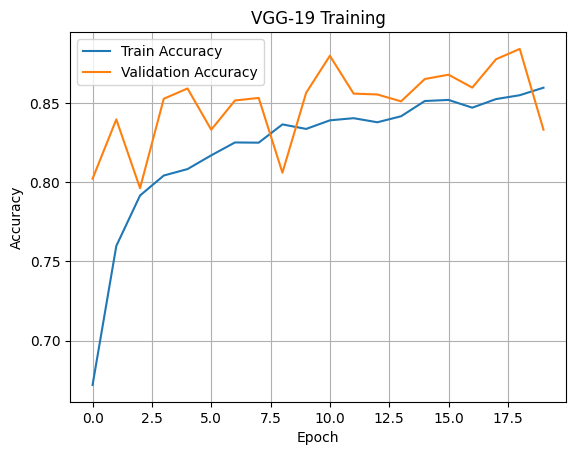

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("VGG-19 Training")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
model.save("/content/drive/MyDrive/pneumonia_project/vgg19_final_model_colab.h5")